In [2]:
import argparse
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.optim.lr_scheduler import StepLR
import sys
import matplotlib.pyplot as plt
import numpy as np
from torchvision.utils import make_grid

In [4]:
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, 1)
        self.conv2 = nn.Conv2d(32, 64, 3, 1)
        self.dropout1 = nn.Dropout(0.25)
        self.dropout2 = nn.Dropout(0.5)
        self.fc1 = nn.Linear(9216, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.conv1(x)
        x = F.relu(x)
        x = self.conv2(x)
        x = F.relu(x)
        x = F.max_pool2d(x, 2)
        x = self.dropout1(x)
        x = torch.flatten(x, 1)
        x = self.fc1(x)
        x = F.relu(x)
        x = self.dropout2(x)
        x = self.fc2(x)
        output = F.log_softmax(x, dim=1)
        return output




In [5]:
def train(args, model, device, train_loader, optimizer, epoch):
    model.train()
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = F.nll_loss(output, target)
        loss.backward()
        optimizer.step()
        if batch_idx % args.log_interval == 0:
            print('Train Epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}'.format(
                epoch, batch_idx * len(data), len(train_loader.dataset),
                100. * batch_idx / len(train_loader), loss.item()))
            if args.dry_run:
                break




In [6]:
def test(model, device, test_loader):
    model.eval()
    test_loss = 0
    correct = 0
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            test_loss += F.nll_loss(output, target, reduction='sum').item()  # sum up batch loss
            pred = output.argmax(dim=1, keepdim=True)  # get the index of the max log-probability
            correct += pred.eq(target.view_as(pred)).sum().item()

    test_loss /= len(test_loader.dataset)

    print('\nTest set: Average loss: {:.4f}, Accuracy: {}/{} ({:.0f}%)\n'.format(
        test_loss, correct, len(test_loader.dataset),
        100. * correct / len(test_loader.dataset)))




In [7]:
def main():
    
    sys.argv = ['']

    # Training settings
    parser = argparse.ArgumentParser(description='PyTorch MNIST Example')
    parser.add_argument('--batch-size', type=int, default=64, metavar='N',
                        help='input batch size for training (default: 64)')
    parser.add_argument('--test-batch-size', type=int, default=1000, metavar='N',
                        help='input batch size for testing (default: 1000)')
    parser.add_argument('--epochs', type=int, default=14, metavar='N',
                        help='number of epochs to train (default: 14)')
    parser.add_argument('--lr', type=float, default=1.0, metavar='LR',
                        help='learning rate (default: 1.0)')
    parser.add_argument('--gamma', type=float, default=0.7, metavar='M',
                        help='Learning rate step gamma (default: 0.7)')
    parser.add_argument('--no-accel', action='store_true',
                        help='disables accelerator')
    parser.add_argument('--dry-run', action='store_true',
                        help='quickly check a single pass')
    parser.add_argument('--seed', type=int, default=1, metavar='S',
                        help='random seed (default: 1)')
    parser.add_argument('--log-interval', type=int, default=10, metavar='N',
                        help='how many batches to wait before logging training status')
    parser.add_argument('--save-model', action='store_true', 
                        help='For Saving the current Model')
    args = parser.parse_args()
    args.save_model = True


    use_accel = not args.no_accel and torch.accelerator.is_available()

    torch.manual_seed(args.seed)

    if use_accel:
        device = torch.accelerator.current_accelerator()
    else:
        device = torch.device("cpu")

    train_kwargs = {'batch_size': args.batch_size}
    test_kwargs = {'batch_size': args.test_batch_size}
    if use_accel:
        accel_kwargs = {'num_workers': 1,
                        'persistent_workers': True,
                       'pin_memory': True,
                       'shuffle': True}
        train_kwargs.update(accel_kwargs)
        test_kwargs.update(accel_kwargs)

    transform=transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))
        ])
    dataset1 = datasets.MNIST('../data', train=True, download=True,
                       transform=transform)
    dataset2 = datasets.MNIST('../data', train=False,
                       transform=transform)
    train_loader = torch.utils.data.DataLoader(dataset1,**train_kwargs)
    test_loader = torch.utils.data.DataLoader(dataset2, **test_kwargs)

    model = Net().to(device)
    optimizer = optim.Adadelta(model.parameters(), lr=args.lr)

    scheduler = StepLR(optimizer, step_size=1, gamma=args.gamma)
    for epoch in range(1, args.epochs + 1):
        train(args, model, device, train_loader, optimizer, epoch)
        test(model, device, test_loader)
        scheduler.step()

    if args.save_model:
        torch.save(model.state_dict(), "mnist_cnn_adadelta.pt")



In [18]:
main()

Train Epoch: 1 [0/60000 (0%)]	Loss: 2.329474
Train Epoch: 1 [640/60000 (1%)]	Loss: 1.425185
Train Epoch: 1 [1280/60000 (2%)]	Loss: 0.826558
Train Epoch: 1 [1920/60000 (3%)]	Loss: 0.549871
Train Epoch: 1 [2560/60000 (4%)]	Loss: 0.466674
Train Epoch: 1 [3200/60000 (5%)]	Loss: 0.237647
Train Epoch: 1 [3840/60000 (6%)]	Loss: 0.345377
Train Epoch: 1 [4480/60000 (7%)]	Loss: 0.339175
Train Epoch: 1 [5120/60000 (9%)]	Loss: 0.549706
Train Epoch: 1 [5760/60000 (10%)]	Loss: 0.149705
Train Epoch: 1 [6400/60000 (11%)]	Loss: 0.178642
Train Epoch: 1 [7040/60000 (12%)]	Loss: 0.223440
Train Epoch: 1 [7680/60000 (13%)]	Loss: 0.170541
Train Epoch: 1 [8320/60000 (14%)]	Loss: 0.125893
Train Epoch: 1 [8960/60000 (15%)]	Loss: 0.256454
Train Epoch: 1 [9600/60000 (16%)]	Loss: 0.151332
Train Epoch: 1 [10240/60000 (17%)]	Loss: 0.518159
Train Epoch: 1 [10880/60000 (18%)]	Loss: 0.179029
Train Epoch: 1 [11520/60000 (19%)]	Loss: 0.683120
Train Epoch: 1 [12160/60000 (20%)]	Loss: 0.163260
Train Epoch: 1 [12800/60000 (

In [21]:
model

Net(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (dropout1): Dropout(p=0.25, inplace=False)
  (dropout2): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=9216, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)

In [8]:
def show_filters(tensor, title="", n_cols=8):
    weights = tensor.detach().cpu().numpy()
    num_filters = weights.shape[0]

    n_rows = (num_filters + n_cols - 1) // n_cols
    plt.figure(figsize=(n_cols, n_rows))

    for i in range(num_filters):
        plt.subplot(n_rows, n_cols, i+1)
        plt.imshow(weights[i, 0], cmap="gray")
        plt.axis("off")

    plt.suptitle(title)
    plt.show()



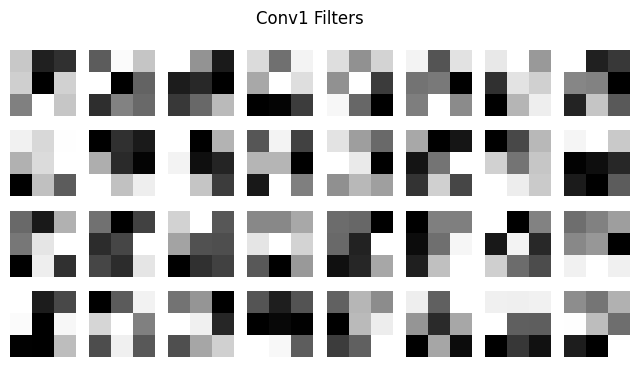

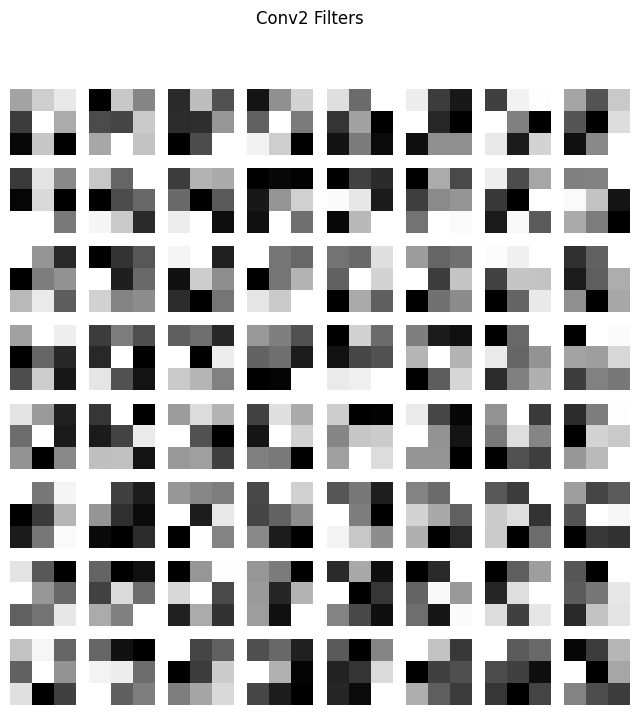

In [89]:
model.load_state_dict(torch.load("mnist_cnn.pt"))
# visualize conv layers
show_filters(model.conv1.weight, "Conv1 Filters")
show_filters(model.conv2.weight, "Conv2 Filters")
# show_filters(model.fc1.weight.view(-1, 1, 16, 8), "FC1 Weights Reshaped")
# show_filters(model.fc2.weight.view(-1, 1, 16, 8), "FC2 Weights Reshaped")



In [13]:
def main_sgd():
    
    sys.argv = ['']

    # Training settings
    parser = argparse.ArgumentParser(description='PyTorch MNIST Example')
    parser.add_argument('--batch-size', type=int, default=64, metavar='N',
                        help='input batch size for training (default: 64)')
    parser.add_argument('--test-batch-size', type=int, default=1000, metavar='N',
                        help='input batch size for testing (default: 1000)')
    parser.add_argument('--epochs', type=int, default=14, metavar='N',
                        help='number of epochs to train (default: 14)')
    parser.add_argument('--lr', type=float, default=1.0, metavar='LR',
                        help='learning rate (default: 1.0)')
    parser.add_argument('--gamma', type=float, default=0.7, metavar='M',
                        help='Learning rate step gamma (default: 0.7)')
    parser.add_argument('--no-accel', action='store_true',
                        help='disables accelerator')
    parser.add_argument('--dry-run', action='store_true',
                        help='quickly check a single pass')
    parser.add_argument('--seed', type=int, default=1, metavar='S',
                        help='random seed (default: 1)')
    parser.add_argument('--log-interval', type=int, default=10, metavar='N',
                        help='how many batches to wait before logging training status')
    parser.add_argument('--save-model', action='store_true', 
                        help='For Saving the current Model')
    args = parser.parse_args()
    args.save_model = True


    use_accel = not args.no_accel and torch.accelerator.is_available()

    torch.manual_seed(args.seed)

    if use_accel:
        device = torch.accelerator.current_accelerator()
    else:
        device = torch.device("cpu")

    train_kwargs = {'batch_size': args.batch_size}
    test_kwargs = {'batch_size': args.test_batch_size}
    if use_accel:
        accel_kwargs = {'num_workers': 1,
                        'persistent_workers': True,
                       'pin_memory': True,
                       'shuffle': True}
        train_kwargs.update(accel_kwargs)
        test_kwargs.update(accel_kwargs)

    transform=transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))
        ])
    dataset1 = datasets.MNIST('../data', train=True, download=True,
                       transform=transform)
    dataset2 = datasets.MNIST('../data', train=False,
                       transform=transform)
    train_loader = torch.utils.data.DataLoader(dataset1,**train_kwargs)
    test_loader = torch.utils.data.DataLoader(dataset2, **test_kwargs)

    model = Net().to(device)

    # optimizer = optim.Adadelta(model.parameters(), lr=args.lr)
    optimizer = optim.SGD(model.parameters(), lr=args.lr)

    scheduler = StepLR(optimizer, step_size=1, gamma=args.gamma)
    for epoch in range(1, args.epochs + 1):
        train(args, model, device, train_loader, optimizer, epoch)
        test(model, device, test_loader)
        scheduler.step()

    if args.save_model:
        torch.save(model.state_dict(), "mnist_cnn_sgd.pt")



In [ ]:
main_sgd()

'''
optimizer = optim.SGD(model.parameters(), lr=0.01)
Test set: Average loss: 0.0882, Accuracy: 9726/10000 (97%)

optimizer = optim.SGD(model.parameters(), lr=1.0)
Test set: Average loss: 0.0395, Accuracy: 9885/10000 (99%)
'''


Train Epoch: 1 [0/60000 (0%)]	Loss: 2.329474
Train Epoch: 1 [640/60000 (1%)]	Loss: 2.077545
Train Epoch: 1 [1280/60000 (2%)]	Loss: 2.297664
Train Epoch: 1 [1920/60000 (3%)]	Loss: 2.284423
Train Epoch: 1 [2560/60000 (4%)]	Loss: 2.311191
Train Epoch: 1 [3200/60000 (5%)]	Loss: 2.263937
Train Epoch: 1 [3840/60000 (6%)]	Loss: 2.326059
Train Epoch: 1 [4480/60000 (7%)]	Loss: 2.742125
Train Epoch: 1 [5120/60000 (9%)]	Loss: 2.163963
Train Epoch: 1 [5760/60000 (10%)]	Loss: 2.329068
Train Epoch: 1 [6400/60000 (11%)]	Loss: 2.296684
Train Epoch: 1 [7040/60000 (12%)]	Loss: 2.318294
Train Epoch: 1 [7680/60000 (13%)]	Loss: 2.324608
Train Epoch: 1 [8320/60000 (14%)]	Loss: 1.902177
Train Epoch: 1 [8960/60000 (15%)]	Loss: 1.751093
Train Epoch: 1 [9600/60000 (16%)]	Loss: 2.021764
Train Epoch: 1 [10240/60000 (17%)]	Loss: 2.044159
Train Epoch: 1 [10880/60000 (18%)]	Loss: 1.433947
Train Epoch: 1 [11520/60000 (19%)]	Loss: 1.767498
Train Epoch: 1 [12160/60000 (20%)]	Loss: 1.233402
Train Epoch: 1 [12800/60000 (

'\noptimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0)\nTest set: Average loss: 0.0882, Accuracy: 9726/10000 (97%)\n\n\n'

In [ ]:
def main_sgdm():
    
    sys.argv = ['']

    # Training settings
    parser = argparse.ArgumentParser(description='PyTorch MNIST Example')
    parser.add_argument('--batch-size', type=int, default=64, metavar='N',
                        help='input batch size for training (default: 64)')
    parser.add_argument('--test-batch-size', type=int, default=1000, metavar='N',
                        help='input batch size for testing (default: 1000)')
    parser.add_argument('--epochs', type=int, default=14, metavar='N',
                        help='number of epochs to train (default: 14)')
    parser.add_argument('--lr', type=float, default=1.0, metavar='LR',
                        help='learning rate (default: 1.0)')
    parser.add_argument('--gamma', type=float, default=0.7, metavar='M',
                        help='Learning rate step gamma (default: 0.7)')
    parser.add_argument('--no-accel', action='store_true',
                        help='disables accelerator')
    parser.add_argument('--dry-run', action='store_true',
                        help='quickly check a single pass')
    parser.add_argument('--seed', type=int, default=1, metavar='S',
                        help='random seed (default: 1)')
    parser.add_argument('--log-interval', type=int, default=10, metavar='N',
                        help='how many batches to wait before logging training status')
    parser.add_argument('--save-model', action='store_true', 
                        help='For Saving the current Model')
    args = parser.parse_args()
    args.save_model = True


    use_accel = not args.no_accel and torch.accelerator.is_available()

    torch.manual_seed(args.seed)

    if use_accel:
        device = torch.accelerator.current_accelerator()
    else:
        device = torch.device("cpu")

    train_kwargs = {'batch_size': args.batch_size}
    test_kwargs = {'batch_size': args.test_batch_size}
    if use_accel:
        accel_kwargs = {'num_workers': 1,
                        'persistent_workers': True,
                       'pin_memory': True,
                       'shuffle': True}
        train_kwargs.update(accel_kwargs)
        test_kwargs.update(accel_kwargs)

    transform=transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))
        ])
    dataset1 = datasets.MNIST('../data', train=True, download=True,
                       transform=transform)
    dataset2 = datasets.MNIST('../data', train=False,
                       transform=transform)
    train_loader = torch.utils.data.DataLoader(dataset1,**train_kwargs)
    test_loader = torch.utils.data.DataLoader(dataset2, **test_kwargs)

    model = Net().to(device)

    # optimizer = optim.Adadelta(model.parameters(), lr=args.lr)
    optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

    scheduler = StepLR(optimizer, step_size=1, gamma=args.gamma)
    for epoch in range(1, args.epochs + 1):
        train(args, model, device, train_loader, optimizer, epoch)
        test(model, device, test_loader)
        scheduler.step()

    if args.save_model:
        torch.save(model.state_dict(), "mnist_cnn_sgdm.pt")

In [ ]:
main_sgdm()

'''
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
Test set: Average loss: 0.0261, Accuracy: 9912/10000 (99%)
'''

Train Epoch: 1 [0/60000 (0%)]	Loss: 2.329474
Train Epoch: 1 [640/60000 (1%)]	Loss: 1.768555
Train Epoch: 1 [1280/60000 (2%)]	Loss: 1.182626
Train Epoch: 1 [1920/60000 (3%)]	Loss: 1.022468
Train Epoch: 1 [2560/60000 (4%)]	Loss: 0.717491
Train Epoch: 1 [3200/60000 (5%)]	Loss: 0.765559
Train Epoch: 1 [3840/60000 (6%)]	Loss: 0.627596
Train Epoch: 1 [4480/60000 (7%)]	Loss: 0.543606
Train Epoch: 1 [5120/60000 (9%)]	Loss: 0.895695
Train Epoch: 1 [5760/60000 (10%)]	Loss: 0.514834
Train Epoch: 1 [6400/60000 (11%)]	Loss: 0.383489
Train Epoch: 1 [7040/60000 (12%)]	Loss: 0.385439
Train Epoch: 1 [7680/60000 (13%)]	Loss: 0.368418
Train Epoch: 1 [8320/60000 (14%)]	Loss: 0.332593
Train Epoch: 1 [8960/60000 (15%)]	Loss: 0.368449
Train Epoch: 1 [9600/60000 (16%)]	Loss: 0.406196
Train Epoch: 1 [10240/60000 (17%)]	Loss: 0.803161
Train Epoch: 1 [10880/60000 (18%)]	Loss: 0.296724
Train Epoch: 1 [11520/60000 (19%)]	Loss: 0.748978
Train Epoch: 1 [12160/60000 (20%)]	Loss: 0.300413
Train Epoch: 1 [12800/60000 (

In [30]:
def main_rmsprop():
    
    sys.argv = ['']

    # Training settings
    parser = argparse.ArgumentParser(description='PyTorch MNIST Example')
    parser.add_argument('--batch-size', type=int, default=64, metavar='N',
                        help='input batch size for training (default: 64)')
    parser.add_argument('--test-batch-size', type=int, default=1000, metavar='N',
                        help='input batch size for testing (default: 1000)')
    parser.add_argument('--epochs', type=int, default=14, metavar='N',
                        help='number of epochs to train (default: 14)')
    parser.add_argument('--lr', type=float, default=1.0, metavar='LR',
                        help='learning rate (default: 1.0)')
    parser.add_argument('--gamma', type=float, default=0.7, metavar='M',
                        help='Learning rate step gamma (default: 0.7)')
    parser.add_argument('--no-accel', action='store_true',
                        help='disables accelerator')
    parser.add_argument('--dry-run', action='store_true',
                        help='quickly check a single pass')
    parser.add_argument('--seed', type=int, default=5, metavar='S',
                        help='random seed (default: 1)')
    parser.add_argument('--log-interval', type=int, default=10, metavar='N',
                        help='how many batches to wait before logging training status')
    parser.add_argument('--save-model', action='store_true', 
                        help='For Saving the current Model')
    args = parser.parse_args()
    args.save_model = True


    use_accel = not args.no_accel and torch.accelerator.is_available()

    torch.manual_seed(args.seed)

    if use_accel:
        device = torch.accelerator.current_accelerator()
    else:
        device = torch.device("cpu")

    train_kwargs = {'batch_size': args.batch_size}
    test_kwargs = {'batch_size': args.test_batch_size}
    if use_accel:
        accel_kwargs = {'num_workers': 1,
                        'persistent_workers': True,
                       'pin_memory': True,
                       'shuffle': True}
        train_kwargs.update(accel_kwargs)
        test_kwargs.update(accel_kwargs)

    transform=transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))
        ])
    dataset1 = datasets.MNIST('../data', train=True, download=True,
                       transform=transform)
    dataset2 = datasets.MNIST('../data', train=False,
                       transform=transform)
    train_loader = torch.utils.data.DataLoader(dataset1,**train_kwargs)
    test_loader = torch.utils.data.DataLoader(dataset2, **test_kwargs)

    model = Net().to(device)

    optimizer = optim.RMSprop(model.parameters(), lr=5.0, alpha=0.99)

    scheduler = StepLR(optimizer, step_size=1, gamma=args.gamma)
    for epoch in range(1, args.epochs + 1):
        train(args, model, device, train_loader, optimizer, epoch)
        test(model, device, test_loader)
        scheduler.step()

    if args.save_model:
        torch.save(model.state_dict(), "mnist_cnn_rmsprop.pt")

In [ ]:
main_rmsprop()

'''
optimizer = optim.RMSprop(model.parameters(), lr=0.01, weight_decay=0.1)
Test set: Average loss: 2.3015, Accuracy: 1135/10000 (11%)

optimizer = optim.RMSprop(model.parameters(), lr=0.1, alpha=0.9)
Test set: Average loss: 2.3011, Accuracy: 1135/10000 (11%)

optimizer = optim.RMSprop(model.parameters(), lr=1.0, alpha=0.9)
Test set: Average loss: 2.3015, Accuracy: 1028/10000 (10%)

optimizer = optim.RMSprop(model.parameters(), lr=1.0, alpha=0.99)
Test set: Average loss: 2.3014, Accuracy: 1028/10000 (10%)

optimizer = optim.RMSprop(model.parameters(), lr=5.0, alpha=0.99)
args.seed = 5
Test set: Average loss: 2.3029, Accuracy: 958/10000 (10%)

optimizer = optim.RMSprop(model.parameters(), lr=0.01, alpha=0.9)

optimizer = optim.RMSprop(model.parameters(), lr=0.01, alpha=0)

optimizer = optim.RMSprop(model.parameters(), lr=0.1, alpha=0)

'''

Train Epoch: 1 [0/60000 (0%)]	Loss: 2.303526
Train Epoch: 1 [640/60000 (1%)]	Loss: 57.942467
Train Epoch: 1 [1280/60000 (2%)]	Loss: 13.951558
Train Epoch: 1 [1920/60000 (3%)]	Loss: 9.742225
Train Epoch: 1 [2560/60000 (4%)]	Loss: 9.137895
Train Epoch: 1 [3200/60000 (5%)]	Loss: 7.656006
Train Epoch: 1 [3840/60000 (6%)]	Loss: 5.785089
Train Epoch: 1 [4480/60000 (7%)]	Loss: 9.182988
Train Epoch: 1 [5120/60000 (9%)]	Loss: 4.803307
Train Epoch: 1 [5760/60000 (10%)]	Loss: 5.529459
Train Epoch: 1 [6400/60000 (11%)]	Loss: 6.382518
Train Epoch: 1 [7040/60000 (12%)]	Loss: 4.925957
Train Epoch: 1 [7680/60000 (13%)]	Loss: 8.948696
Train Epoch: 1 [8320/60000 (14%)]	Loss: 5.449352
Train Epoch: 1 [8960/60000 (15%)]	Loss: 7.823822
Train Epoch: 1 [9600/60000 (16%)]	Loss: 6.029291
Train Epoch: 1 [10240/60000 (17%)]	Loss: 3.470371
Train Epoch: 1 [10880/60000 (18%)]	Loss: 5.524189
Train Epoch: 1 [11520/60000 (19%)]	Loss: 6.641585
Train Epoch: 1 [12160/60000 (20%)]	Loss: 4.544611
Train Epoch: 1 [12800/60000

'\noptimizer = optim.RMSprop(model.parameters(), lr=0.01, weight_decay=0.1)\nTest set: Average loss: 2.3015, Accuracy: 1135/10000 (11%)\n\noptimizer = optim.RMSprop(model.parameters(), lr=0.1, alpha=0.9)\nTest set: Average loss: 2.3011, Accuracy: 1135/10000 (11%)\n\noptimizer = optim.RMSprop(model.parameters(), lr=1.0, alpha=0.9)\nTest set: Average loss: 2.3015, Accuracy: 1028/10000 (10%)\n\noptimizer = optim.RMSprop(model.parameters(), lr=1.0, alpha=0.99)\nTest set: Average loss: 2.3014, Accuracy: 1028/10000 (10%)\n\noptimizer = optim.RMSprop(model.parameters(), lr=5.0, alpha=0.99)\nargs.seed = 5\n\n'

In [ ]:
def main_adam():
    
    sys.argv = ['']

    # Training settings
    parser = argparse.ArgumentParser(description='PyTorch MNIST Example')
    parser.add_argument('--batch-size', type=int, default=64, metavar='N',
                        help='input batch size for training (default: 64)')
    parser.add_argument('--test-batch-size', type=int, default=1000, metavar='N',
                        help='input batch size for testing (default: 1000)')
    parser.add_argument('--epochs', type=int, default=14, metavar='N',
                        help='number of epochs to train (default: 14)')
    parser.add_argument('--lr', type=float, default=1.0, metavar='LR',
                        help='learning rate (default: 1.0)')
    parser.add_argument('--gamma', type=float, default=0.7, metavar='M',
                        help='Learning rate step gamma (default: 0.7)')
    parser.add_argument('--no-accel', action='store_true',
                        help='disables accelerator')
    parser.add_argument('--dry-run', action='store_true',
                        help='quickly check a single pass')
    parser.add_argument('--seed', type=int, default=1, metavar='S',
                        help='random seed (default: 1)')
    parser.add_argument('--log-interval', type=int, default=10, metavar='N',
                        help='how many batches to wait before logging training status')
    parser.add_argument('--save-model', action='store_true', 
                        help='For Saving the current Model')
    args = parser.parse_args()
    args.save_model = True


    use_accel = not args.no_accel and torch.accelerator.is_available()

    torch.manual_seed(args.seed)

    if use_accel:
        device = torch.accelerator.current_accelerator()
    else:
        device = torch.device("cpu")

    train_kwargs = {'batch_size': args.batch_size}
    test_kwargs = {'batch_size': args.test_batch_size}
    if use_accel:
        accel_kwargs = {'num_workers': 1,
                        'persistent_workers': True,
                       'pin_memory': True,
                       'shuffle': True}
        train_kwargs.update(accel_kwargs)
        test_kwargs.update(accel_kwargs)

    transform=transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))
        ])
    dataset1 = datasets.MNIST('../data', train=True, download=True,
                       transform=transform)
    dataset2 = datasets.MNIST('../data', train=False,
                       transform=transform)
    train_loader = torch.utils.data.DataLoader(dataset1,**train_kwargs)
    test_loader = torch.utils.data.DataLoader(dataset2, **test_kwargs)

    model = Net().to(device)

    optimizer = optim.Adam(model.parameters(), lr=0.01, betas=(0.9, 0.999))

    scheduler = StepLR(optimizer, step_size=1, gamma=args.gamma)
    for epoch in range(1, args.epochs + 1):
        train(args, model, device, train_loader, optimizer, epoch)
        test(model, device, test_loader)
        scheduler.step()

    if args.save_model:
        torch.save(model.state_dict(), "mnist_cnn_adam.pt")

In [ ]:
main_adam()

'''
optimizer = optim.Adam(model.parameters(), lr=0.01, betas=(0.9, 0.999))
Test set: Average loss: 0.0603, Accuracy: 9816/10000 (98%)

'''

Train Epoch: 1 [0/60000 (0%)]	Loss: 2.329474
Train Epoch: 1 [640/60000 (1%)]	Loss: 1.682468
Train Epoch: 1 [1280/60000 (2%)]	Loss: 0.986242
Train Epoch: 1 [1920/60000 (3%)]	Loss: 0.769906
Train Epoch: 1 [2560/60000 (4%)]	Loss: 0.692919
Train Epoch: 1 [3200/60000 (5%)]	Loss: 0.551353
Train Epoch: 1 [3840/60000 (6%)]	Loss: 0.472024
Train Epoch: 1 [4480/60000 (7%)]	Loss: 0.460984
Train Epoch: 1 [5120/60000 (9%)]	Loss: 0.522712
Train Epoch: 1 [5760/60000 (10%)]	Loss: 0.554773
Train Epoch: 1 [6400/60000 (11%)]	Loss: 0.287389
Train Epoch: 1 [7040/60000 (12%)]	Loss: 0.358566
Train Epoch: 1 [7680/60000 (13%)]	Loss: 0.453527
Train Epoch: 1 [8320/60000 (14%)]	Loss: 0.375222
Train Epoch: 1 [8960/60000 (15%)]	Loss: 0.411058
Train Epoch: 1 [9600/60000 (16%)]	Loss: 0.852222
Train Epoch: 1 [10240/60000 (17%)]	Loss: 0.752232
Train Epoch: 1 [10880/60000 (18%)]	Loss: 0.282364
Train Epoch: 1 [11520/60000 (19%)]	Loss: 0.498258
Train Epoch: 1 [12160/60000 (20%)]	Loss: 0.409728
Train Epoch: 1 [12800/60000 (

'\noptimizer = optim.Adam(model.parameters(), lr=0.01, betas=(0.9, 0.999))\n\n\n'

In [ ]:
class Net_noDropout(nn.Module):
    def __init__(self):
        super(Net_noDropout, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, 1)
        self.conv2 = nn.Conv2d(32, 64, 3, 1)
        # self.dropout1 = nn.Dropout(0.25)
        # self.dropout2 = nn.Dropout(0.5)
        self.fc1 = nn.Linear(9216, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.conv1(x)
        x = F.relu(x)
        x = self.conv2(x)
        x = F.relu(x)
        x = F.max_pool2d(x, 2)
        # x = self.dropout1(x)
        x = torch.flatten(x, 1)
        x = self.fc1(x)
        x = F.relu(x)
        # x = self.dropout2(x)
        x = self.fc2(x)
        output = F.log_softmax(x, dim=1)
        return output




In [37]:
def main_sgdm_nodropout():
    
    sys.argv = ['']

    # Training settings
    parser = argparse.ArgumentParser(description='PyTorch MNIST Example')
    parser.add_argument('--batch-size', type=int, default=64, metavar='N',
                        help='input batch size for training (default: 64)')
    parser.add_argument('--test-batch-size', type=int, default=1000, metavar='N',
                        help='input batch size for testing (default: 1000)')
    parser.add_argument('--epochs', type=int, default=14, metavar='N',
                        help='number of epochs to train (default: 14)')
    parser.add_argument('--lr', type=float, default=1.0, metavar='LR',
                        help='learning rate (default: 1.0)')
    parser.add_argument('--gamma', type=float, default=0.7, metavar='M',
                        help='Learning rate step gamma (default: 0.7)')
    parser.add_argument('--no-accel', action='store_true',
                        help='disables accelerator')
    parser.add_argument('--dry-run', action='store_true',
                        help='quickly check a single pass')
    parser.add_argument('--seed', type=int, default=1, metavar='S',
                        help='random seed (default: 1)')
    parser.add_argument('--log-interval', type=int, default=10, metavar='N',
                        help='how many batches to wait before logging training status')
    parser.add_argument('--save-model', action='store_true', 
                        help='For Saving the current Model')
    args = parser.parse_args()
    args.save_model = True


    use_accel = not args.no_accel and torch.accelerator.is_available()

    torch.manual_seed(args.seed)

    if use_accel:
        device = torch.accelerator.current_accelerator()
    else:
        device = torch.device("cpu")

    train_kwargs = {'batch_size': args.batch_size}
    test_kwargs = {'batch_size': args.test_batch_size}
    if use_accel:
        accel_kwargs = {'num_workers': 1,
                        'persistent_workers': True,
                       'pin_memory': True,
                       'shuffle': True}
        train_kwargs.update(accel_kwargs)
        test_kwargs.update(accel_kwargs)

    transform=transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))
        ])
    dataset1 = datasets.MNIST('../data', train=True, download=True,
                       transform=transform)
    dataset2 = datasets.MNIST('../data', train=False,
                       transform=transform)
    train_loader = torch.utils.data.DataLoader(dataset1,**train_kwargs)
    test_loader = torch.utils.data.DataLoader(dataset2, **test_kwargs)

    model = Net_noDropout().to(device)

    # optimizer = optim.Adadelta(model.parameters(), lr=args.lr)
    optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

    scheduler = StepLR(optimizer, step_size=1, gamma=args.gamma)
    for epoch in range(1, args.epochs + 1):
        train(args, model, device, train_loader, optimizer, epoch)
        test(model, device, test_loader)
        scheduler.step()

    if args.save_model:
        torch.save(model.state_dict(), "mnist_cnn_sgdm_nodropout.pt")

In [ ]:
main_sgdm_nodropout()

'''
model = Net_noDropout().to(device)
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
Test set: Average loss: 0.0296, Accuracy: 9906/10000 (99%)

smaller sample size to highlight overfitting without dropout

less epochs
'''


Train Epoch: 1 [0/60000 (0%)]	Loss: 2.290957
Train Epoch: 1 [640/60000 (1%)]	Loss: 1.589589
Train Epoch: 1 [1280/60000 (2%)]	Loss: 0.783642
Train Epoch: 1 [1920/60000 (3%)]	Loss: 0.713360
Train Epoch: 1 [2560/60000 (4%)]	Loss: 0.326350
Train Epoch: 1 [3200/60000 (5%)]	Loss: 0.366399
Train Epoch: 1 [3840/60000 (6%)]	Loss: 0.208597
Train Epoch: 1 [4480/60000 (7%)]	Loss: 0.279556
Train Epoch: 1 [5120/60000 (9%)]	Loss: 0.682553
Train Epoch: 1 [5760/60000 (10%)]	Loss: 0.303070
Train Epoch: 1 [6400/60000 (11%)]	Loss: 0.245524
Train Epoch: 1 [7040/60000 (12%)]	Loss: 0.130977
Train Epoch: 1 [7680/60000 (13%)]	Loss: 0.252174
Train Epoch: 1 [8320/60000 (14%)]	Loss: 0.134118
Train Epoch: 1 [8960/60000 (15%)]	Loss: 0.225357
Train Epoch: 1 [9600/60000 (16%)]	Loss: 0.287443
Train Epoch: 1 [10240/60000 (17%)]	Loss: 0.361402
Train Epoch: 1 [10880/60000 (18%)]	Loss: 0.188246
Train Epoch: 1 [11520/60000 (19%)]	Loss: 0.530619
Train Epoch: 1 [12160/60000 (20%)]	Loss: 0.226236
Train Epoch: 1 [12800/60000 (

'\nmodel = Net_noDropout().to(device)\noptimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)\nTest set: Average loss: 0.0296, Accuracy: 9906/10000 (99%)\n'

tensor([[[[ 0.1546, -0.1279,  0.0060],
          [ 0.3014,  0.0208, -0.0952],
          [-0.0553, -0.1887, -0.2396]]],


        [[[-0.1284, -0.3100,  0.2135],
          [ 0.0586,  0.3154,  0.3085],
          [ 0.1835,  0.0221,  0.2448]]],


        [[[ 0.3305, -0.2168,  0.0647],
          [-0.3223,  0.2064, -0.0312],
          [ 0.2848,  0.2624,  0.1899]]],


        [[[ 0.2289,  0.1780, -0.0513],
          [-0.1814,  0.2392, -0.1478],
          [-0.0978,  0.2308, -0.1116]]],


        [[[-0.0178, -0.2072,  0.2734],
          [ 0.0463, -0.0479, -0.0965],
          [-0.3159, -0.0565, -0.3098]]],


        [[[ 0.2983,  0.1564, -0.0656],
          [ 0.0783,  0.2243,  0.0060],
          [-0.2578, -0.1873, -0.2903]]],


        [[[-0.3092,  0.1844, -0.0714],
          [ 0.0638, -0.0959,  0.3185],
          [-0.0493, -0.3193,  0.0185]]],


        [[[ 0.0857,  0.0201, -0.0895],
          [ 0.2569,  0.2824,  0.0489],
          [ 0.2343, -0.0660,  0.2935]]],


        [[[-0.2436,  0.2872, -0.

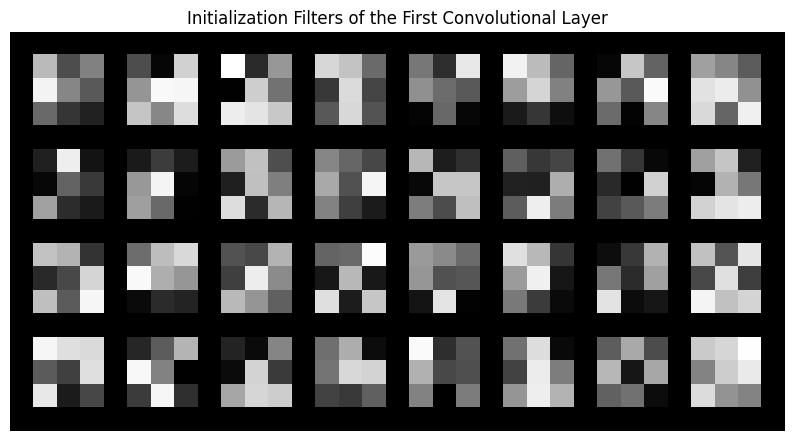

In [35]:
# Check initialization of convolutional layer filters

model = Net()
print(model.conv1.weight.data)

def visualize_filters(weights_tensor, nrow=8):
    weights_tensor = weights_tensor - weights_tensor.min()
    weights_tensor = weights_tensor / weights_tensor.max()
    grid = make_grid(weights_tensor, nrow=nrow, normalize=True, padding=1)
    image_grid = grid.permute(1, 2, 0)
    return image_grid

filter_image_grid = visualize_filters(model.conv1.weight.data)
plt.figure(figsize=(10, 10))
plt.imshow(filter_image_grid)
plt.axis('off')
plt.title('Initialization Filters of the First Convolutional Layer')
plt.show()

# how did they get these values for initialization?

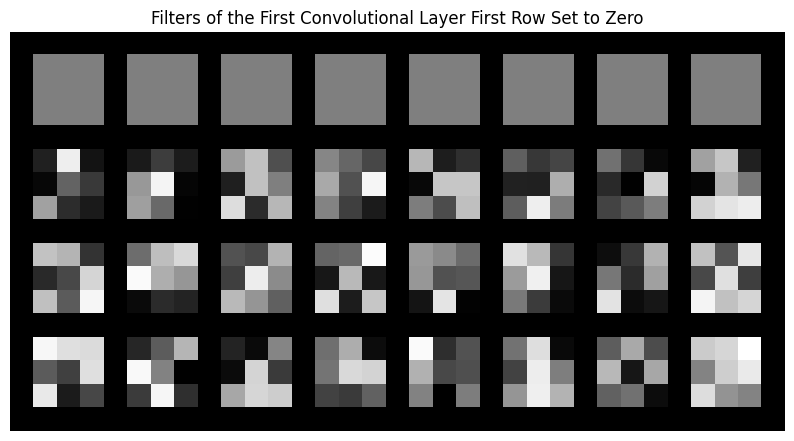

In [36]:
# Set first row to zeros
model.conv1.weight.data[0:8].zero_()
filter_image_grid_zero = visualize_filters(model.conv1.weight.data)
plt.figure(figsize=(10, 10))
plt.imshow(filter_image_grid_zero)
plt.axis('off')
plt.title('Filters of the First Convolutional Layer First Row Set to Zero')
plt.show()


tensor([[[[0., 0., 0.],
          [0., 0., 0.],
          [0., 0., 0.]]],


        [[[0., 0., 0.],
          [0., 0., 0.],
          [0., 0., 0.]]],


        [[[0., 0., 0.],
          [0., 0., 0.],
          [0., 0., 0.]]],


        [[[0., 0., 0.],
          [0., 0., 0.],
          [0., 0., 0.]]],


        [[[0., 0., 0.],
          [0., 0., 0.],
          [0., 0., 0.]]],


        [[[0., 0., 0.],
          [0., 0., 0.],
          [0., 0., 0.]]],


        [[[0., 0., 0.],
          [0., 0., 0.],
          [0., 0., 0.]]],


        [[[0., 0., 0.],
          [0., 0., 0.],
          [0., 0., 0.]]],


        [[[0., 0., 0.],
          [0., 0., 0.],
          [0., 0., 0.]]],


        [[[0., 0., 0.],
          [0., 0., 0.],
          [0., 0., 0.]]],


        [[[0., 0., 0.],
          [0., 0., 0.],
          [0., 0., 0.]]],


        [[[0., 0., 0.],
          [0., 0., 0.],
          [0., 0., 0.]]],


        [[[0., 0., 0.],
          [0., 0., 0.],
          [0., 0., 0.]]],


        [[[0

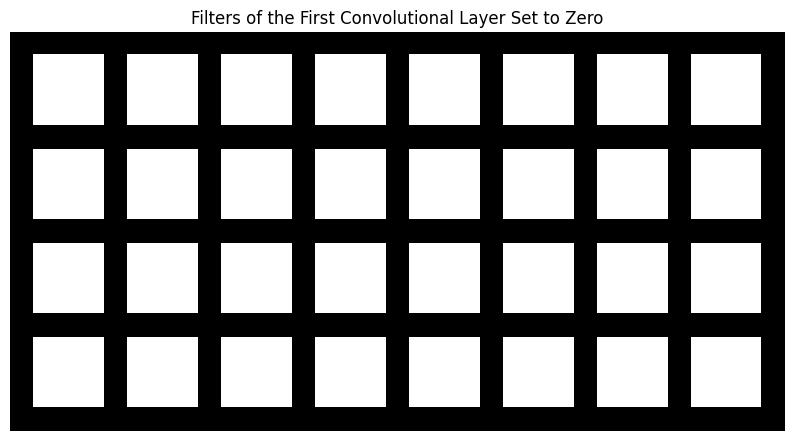

In [37]:
# Observe training with zeroed filters
model.conv1.weight.data.zero_()
print(model.conv1.weight.data)
filter_image_grid_zero = visualize_filters(model.conv1.weight.data)
plt.figure(figsize=(10, 10))
plt.imshow(filter_image_grid_zero)
plt.axis('off')
plt.title('Filters of the First Convolutional Layer Set to Zero')
plt.show()

In [39]:
def main_sgdm_zeroed():
    
    sys.argv = ['']

    # Training settings
    parser = argparse.ArgumentParser(description='PyTorch MNIST Example')
    parser.add_argument('--batch-size', type=int, default=64, metavar='N',
                        help='input batch size for training (default: 64)')
    parser.add_argument('--test-batch-size', type=int, default=1000, metavar='N',
                        help='input batch size for testing (default: 1000)')
    parser.add_argument('--epochs', type=int, default=14, metavar='N',
                        help='number of epochs to train (default: 14)')
    parser.add_argument('--lr', type=float, default=1.0, metavar='LR',
                        help='learning rate (default: 1.0)')
    parser.add_argument('--gamma', type=float, default=0.7, metavar='M',
                        help='Learning rate step gamma (default: 0.7)')
    parser.add_argument('--no-accel', action='store_true',
                        help='disables accelerator')
    parser.add_argument('--dry-run', action='store_true',
                        help='quickly check a single pass')
    parser.add_argument('--seed', type=int, default=1, metavar='S',
                        help='random seed (default: 1)')
    parser.add_argument('--log-interval', type=int, default=10, metavar='N',
                        help='how many batches to wait before logging training status')
    parser.add_argument('--save-model', action='store_true', 
                        help='For Saving the current Model')
    args = parser.parse_args()
    args.save_model = True


    use_accel = not args.no_accel and torch.accelerator.is_available()

    torch.manual_seed(args.seed)

    if use_accel:
        device = torch.accelerator.current_accelerator()
    else:
        device = torch.device("cpu")

    train_kwargs = {'batch_size': args.batch_size}
    test_kwargs = {'batch_size': args.test_batch_size}
    if use_accel:
        accel_kwargs = {'num_workers': 1,
                        'persistent_workers': True,
                       'pin_memory': True,
                       'shuffle': True}
        train_kwargs.update(accel_kwargs)
        test_kwargs.update(accel_kwargs)

    transform=transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))
        ])
    dataset1 = datasets.MNIST('../data', train=True, download=True,
                       transform=transform)
    dataset2 = datasets.MNIST('../data', train=False,
                       transform=transform)
    train_loader = torch.utils.data.DataLoader(dataset1,**train_kwargs)
    test_loader = torch.utils.data.DataLoader(dataset2, **test_kwargs)

    model = Net().to(device)
    model.conv1.weight.data.zero_()
    model.conv2.weight.data.zero_()
    model.fc1.weight.data.zero_()
    model.fc2.weight.data.zero_()
    model.conv1.bias.data.zero_()
    model.conv2.bias.data.zero_()
    model.fc1.bias.data.zero_()
    model.fc2.bias.data.zero_()

    # optimizer = optim.Adadelta(model.parameters(), lr=args.lr)
    optimizer = optim.SGD(model.parameters(), lr=0.1, momentum=0.9)

    scheduler = StepLR(optimizer, step_size=1, gamma=args.gamma)
    for epoch in range(1, args.epochs + 1):
        train(args, model, device, train_loader, optimizer, epoch)
        test(model, device, test_loader)
        scheduler.step()

    if args.save_model:
        torch.save(model.state_dict(), "mnist_cnn_sgdm_zeroed.pt")

In [40]:
main_sgdm_zeroed()

'''
conv1 weights  initialized to zero
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
Test set: Average loss: 0.0292, Accuracy: 9909/10000 (99%)

conv1, conv2, fc1, fc2 weights and biases all initialized to zero
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
Test set: Average loss: 2.3010, Accuracy: 1135/10000 (11%)

optimizer = optim.SGD(model.parameters(), lr=0.1, momentum=0.9)
'''

Train Epoch: 1 [0/60000 (0%)]	Loss: 2.302585
Train Epoch: 1 [640/60000 (1%)]	Loss: 2.299675
Train Epoch: 1 [1280/60000 (2%)]	Loss: 2.307856
Train Epoch: 1 [1920/60000 (3%)]	Loss: 2.299567
Train Epoch: 1 [2560/60000 (4%)]	Loss: 2.303746
Train Epoch: 1 [3200/60000 (5%)]	Loss: 2.304118
Train Epoch: 1 [3840/60000 (6%)]	Loss: 2.301752
Train Epoch: 1 [4480/60000 (7%)]	Loss: 2.299236
Train Epoch: 1 [5120/60000 (9%)]	Loss: 2.298639
Train Epoch: 1 [5760/60000 (10%)]	Loss: 2.288369
Train Epoch: 1 [6400/60000 (11%)]	Loss: 2.293234
Train Epoch: 1 [7040/60000 (12%)]	Loss: 2.297627
Train Epoch: 1 [7680/60000 (13%)]	Loss: 2.308188
Train Epoch: 1 [8320/60000 (14%)]	Loss: 2.298060
Train Epoch: 1 [8960/60000 (15%)]	Loss: 2.280191
Train Epoch: 1 [9600/60000 (16%)]	Loss: 2.291197
Train Epoch: 1 [10240/60000 (17%)]	Loss: 2.296446
Train Epoch: 1 [10880/60000 (18%)]	Loss: 2.309552
Train Epoch: 1 [11520/60000 (19%)]	Loss: 2.296255
Train Epoch: 1 [12160/60000 (20%)]	Loss: 2.297983
Train Epoch: 1 [12800/60000 (

'\nconv1 weights  initialized to zero\noptimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)\nTest set: Average loss: 0.0292, Accuracy: 9909/10000 (99%)\n\nconv1, conv2, fc1, fc2 weights and biases all initialized to zero\noptimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)\nTest set: Average loss: 2.3010, Accuracy: 1135/10000 (11%)\n\noptimizer = optim.SGD(model.parameters(), lr=0.1, momentum=0.9)\n'

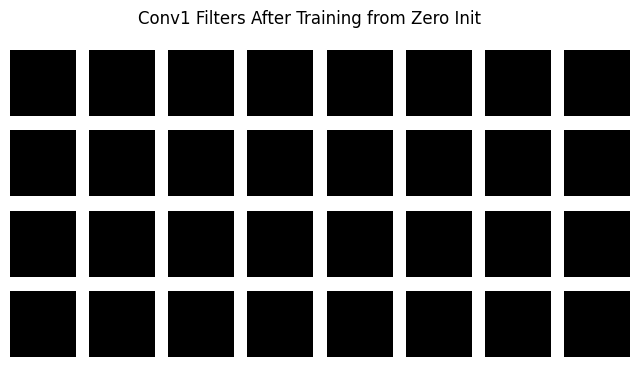

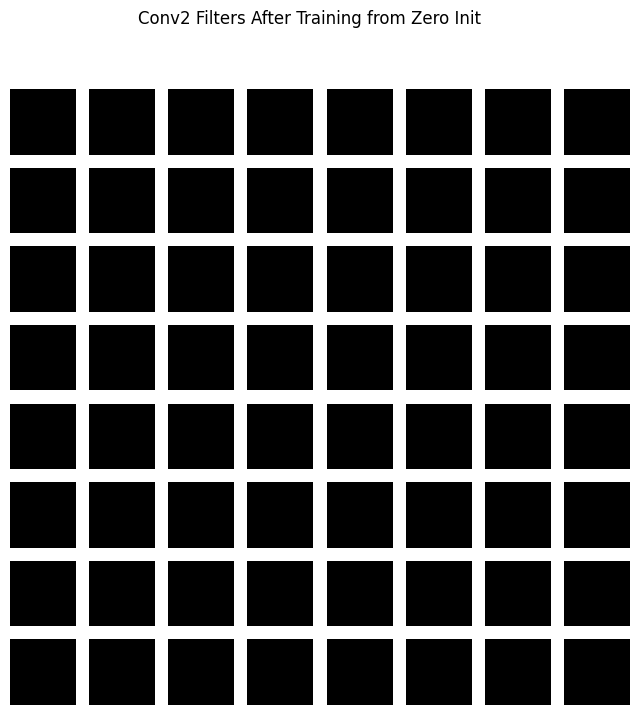

In [34]:
model = Net()
model.load_state_dict(torch.load("mnist_cnn_sgdm_zeroed.pt"))
# visualize conv layers
show_filters(model.conv1.weight, "Conv1 Filters After Training from Zero Init")
show_filters(model.conv2.weight, "Conv2 Filters After Training from Zero Init")

In [10]:
class Net_LayerNorm(nn.Module):
    def __init__(self):
        super(Net_LayerNorm, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, 1)
        self.conv2 = nn.Conv2d(32, 64, 3, 1)
        self.dropout1 = nn.Dropout(0.25)
        self.dropout2 = nn.Dropout(0.5)
        self.fc1 = nn.Linear(9216, 128)
        self.fc2 = nn.Linear(128, 10)
        self.ln1 = nn.LayerNorm([32, 26, 26])
        self.ln2 = nn.LayerNorm([64, 24, 24])

    def forward(self, x):
        x = self.conv1(x)
        x = self.ln1(x)
        x = F.relu(x)
        x = self.conv2(x)
        x = self.ln2(x)
        x = F.relu(x)
        x = F.max_pool2d(x, 2)
        x = self.dropout1(x)
        x = torch.flatten(x, 1)
        x = self.fc1(x)
        x = F.relu(x)
        x = self.dropout2(x)
        x = self.fc2(x)
        output = F.log_softmax(x, dim=1)
        return output


In [11]:
def main_adam_layernorm():
    
    sys.argv = ['']

    # Training settings
    parser = argparse.ArgumentParser(description='PyTorch MNIST Example')
    parser.add_argument('--batch-size', type=int, default=64, metavar='N',
                        help='input batch size for training (default: 64)')
    parser.add_argument('--test-batch-size', type=int, default=1000, metavar='N',
                        help='input batch size for testing (default: 1000)')
    parser.add_argument('--epochs', type=int, default=14, metavar='N',
                        help='number of epochs to train (default: 14)')
    parser.add_argument('--lr', type=float, default=1.0, metavar='LR',
                        help='learning rate (default: 1.0)')
    parser.add_argument('--gamma', type=float, default=0.7, metavar='M',
                        help='Learning rate step gamma (default: 0.7)')
    parser.add_argument('--no-accel', action='store_true',
                        help='disables accelerator')
    parser.add_argument('--dry-run', action='store_true',
                        help='quickly check a single pass')
    parser.add_argument('--seed', type=int, default=1, metavar='S',
                        help='random seed (default: 1)')
    parser.add_argument('--log-interval', type=int, default=10, metavar='N',
                        help='how many batches to wait before logging training status')
    parser.add_argument('--save-model', action='store_true', 
                        help='For Saving the current Model')
    args = parser.parse_args()
    args.save_model = True


    use_accel = not args.no_accel and torch.accelerator.is_available()

    torch.manual_seed(args.seed)

    if use_accel:
        device = torch.accelerator.current_accelerator()
    else:
        device = torch.device("cpu")

    train_kwargs = {'batch_size': args.batch_size}
    test_kwargs = {'batch_size': args.test_batch_size}
    if use_accel:
        accel_kwargs = {'num_workers': 1,
                        'persistent_workers': True,
                       'pin_memory': True,
                       'shuffle': True}
        train_kwargs.update(accel_kwargs)
        test_kwargs.update(accel_kwargs)

    transform=transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))
        ])
    dataset1 = datasets.MNIST('../data', train=True, download=True,
                       transform=transform)
    dataset2 = datasets.MNIST('../data', train=False,
                       transform=transform)
    train_loader = torch.utils.data.DataLoader(dataset1,**train_kwargs)
    test_loader = torch.utils.data.DataLoader(dataset2, **test_kwargs)

    model = Net_LayerNorm().to(device)

    optimizer = optim.Adam(model.parameters(), lr=0.01, betas=(0.9, 0.999))

    scheduler = StepLR(optimizer, step_size=1, gamma=args.gamma)
    for epoch in range(1, args.epochs + 1):
        train(args, model, device, train_loader, optimizer, epoch)
        test(model, device, test_loader)
        scheduler.step()

    if args.save_model:
        torch.save(model.state_dict(), "mnist_cnn_adam_layernorm.pt")

In [12]:
main_adam_layernorm()
'''
LayerNorm model with Adam optimizer
optimizer = optim.Adam(model.parameters(), lr=0.01, betas=(0.9, 0.999))
Test set: Average loss: 0.0566, Accuracy: 9858/10000 (99%)

'''

Train Epoch: 1 [0/60000 (0%)]	Loss: 2.420038
Train Epoch: 1 [640/60000 (1%)]	Loss: 1.796321
Train Epoch: 1 [1280/60000 (2%)]	Loss: 1.549538
Train Epoch: 1 [1920/60000 (3%)]	Loss: 1.379646
Train Epoch: 1 [2560/60000 (4%)]	Loss: 1.657637
Train Epoch: 1 [3200/60000 (5%)]	Loss: 1.259333
Train Epoch: 1 [3840/60000 (6%)]	Loss: 1.394978
Train Epoch: 1 [4480/60000 (7%)]	Loss: 1.177463
Train Epoch: 1 [5120/60000 (9%)]	Loss: 1.566705
Train Epoch: 1 [5760/60000 (10%)]	Loss: 1.177794
Train Epoch: 1 [6400/60000 (11%)]	Loss: 1.292620
Train Epoch: 1 [7040/60000 (12%)]	Loss: 1.233553
Train Epoch: 1 [7680/60000 (13%)]	Loss: 1.035632
Train Epoch: 1 [8320/60000 (14%)]	Loss: 1.337056
Train Epoch: 1 [8960/60000 (15%)]	Loss: 1.179683
Train Epoch: 1 [9600/60000 (16%)]	Loss: 1.469626
Train Epoch: 1 [10240/60000 (17%)]	Loss: 1.389325
Train Epoch: 1 [10880/60000 (18%)]	Loss: 1.253484
Train Epoch: 1 [11520/60000 (19%)]	Loss: 1.156397
Train Epoch: 1 [12160/60000 (20%)]	Loss: 1.434880
Train Epoch: 1 [12800/60000 (

'\nLayerNorm model with Adam optimizer\noptimizer = optim.Adam(model.parameters(), lr=0.01, betas=(0.9, 0.999))\nTest set: Average loss: 0.0566, Accuracy: 9858/10000 (99%)\n\n'

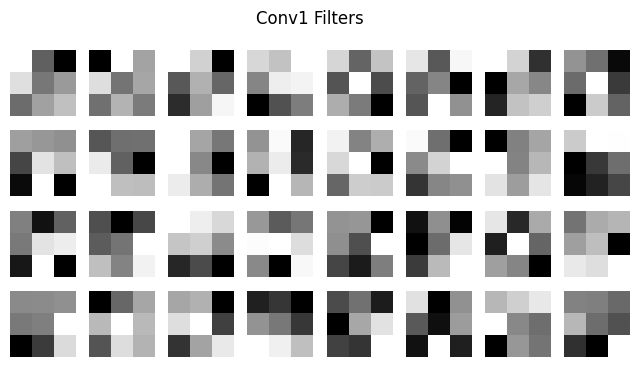

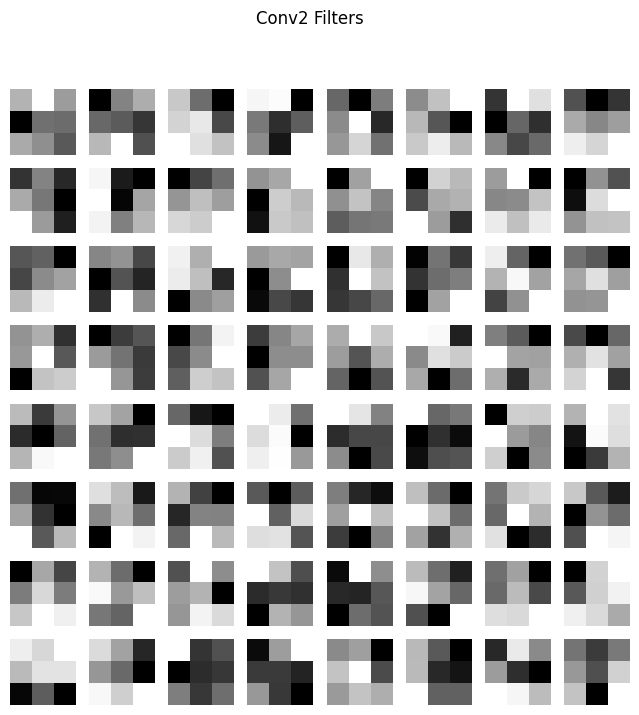

In [19]:
model = Net_LayerNorm()
model.load_state_dict(torch.load("mnist_cnn_adam_layernorm.pt"))
# visualize conv layers
show_filters(model.conv1.weight, "Conv1 Filters")
show_filters(model.conv2.weight, "Conv2 Filters")
# show_filters(model.fc1.weight.view(-1, 1, 16, 8), "FC1 Weights Reshaped")
# show_filters(model.fc2.weight.view(-1, 1, 16, 8), "FC2 Weights Reshaped")



In [20]:
class Net_BatchNorm(nn.Module):
    def __init__(self):
        super(Net_BatchNorm, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, 1)
        self.conv2 = nn.Conv2d(32, 64, 3, 1)
        self.dropout1 = nn.Dropout(0.25)
        self.dropout2 = nn.Dropout(0.5)
        self.fc1 = nn.Linear(9216, 128)
        self.fc2 = nn.Linear(128, 10)
        self.bn1 = nn.BatchNorm2d(32)
        self.bn2 = nn.BatchNorm2d(64)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.conv2(x)
        x = self.bn2(x)
        x = F.relu(x)
        x = F.max_pool2d(x, 2)
        x = self.dropout1(x)
        x = torch.flatten(x, 1)
        x = self.fc1(x)
        x = F.relu(x)
        x = self.dropout2(x)
        x = self.fc2(x)
        output = F.log_softmax(x, dim=1)
        return output


In [21]:
def main_adam_batchnorm():
    
    sys.argv = ['']

    # Training settings
    parser = argparse.ArgumentParser(description='PyTorch MNIST Example')
    parser.add_argument('--batch-size', type=int, default=64, metavar='N',
                        help='input batch size for training (default: 64)')
    parser.add_argument('--test-batch-size', type=int, default=1000, metavar='N',
                        help='input batch size for testing (default: 1000)')
    parser.add_argument('--epochs', type=int, default=14, metavar='N',
                        help='number of epochs to train (default: 14)')
    parser.add_argument('--lr', type=float, default=1.0, metavar='LR',
                        help='learning rate (default: 1.0)')
    parser.add_argument('--gamma', type=float, default=0.7, metavar='M',
                        help='Learning rate step gamma (default: 0.7)')
    parser.add_argument('--no-accel', action='store_true',
                        help='disables accelerator')
    parser.add_argument('--dry-run', action='store_true',
                        help='quickly check a single pass')
    parser.add_argument('--seed', type=int, default=1, metavar='S',
                        help='random seed (default: 1)')
    parser.add_argument('--log-interval', type=int, default=10, metavar='N',
                        help='how many batches to wait before logging training status')
    parser.add_argument('--save-model', action='store_true', 
                        help='For Saving the current Model')
    args = parser.parse_args()
    args.save_model = True


    use_accel = not args.no_accel and torch.accelerator.is_available()

    torch.manual_seed(args.seed)

    if use_accel:
        device = torch.accelerator.current_accelerator()
    else:
        device = torch.device("cpu")

    train_kwargs = {'batch_size': args.batch_size}
    test_kwargs = {'batch_size': args.test_batch_size}
    if use_accel:
        accel_kwargs = {'num_workers': 1,
                        'persistent_workers': True,
                       'pin_memory': True,
                       'shuffle': True}
        train_kwargs.update(accel_kwargs)
        test_kwargs.update(accel_kwargs)

    transform=transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))
        ])
    dataset1 = datasets.MNIST('../data', train=True, download=True,
                       transform=transform)
    dataset2 = datasets.MNIST('../data', train=False,
                       transform=transform)
    train_loader = torch.utils.data.DataLoader(dataset1,**train_kwargs)
    test_loader = torch.utils.data.DataLoader(dataset2, **test_kwargs)

    model = Net_BatchNorm().to(device)

    optimizer = optim.Adam(model.parameters(), lr=0.01, betas=(0.9, 0.999))

    scheduler = StepLR(optimizer, step_size=1, gamma=args.gamma)
    for epoch in range(1, args.epochs + 1):
        train(args, model, device, train_loader, optimizer, epoch)
        test(model, device, test_loader)
        scheduler.step()

    if args.save_model:
        torch.save(model.state_dict(), "mnist_cnn_adam_batchnorm.pt")

In [ ]:
main_adam_batchnorm()
'''
BatchNorm model with Adam optimizer
optimizer = optim.Adam(model.parameters(), lr=0.01, betas=(0.9, 0.999))
Test set: Average loss: 0.0350, Accuracy: 9907/10000 (99%)

'''

Train Epoch: 1 [0/60000 (0%)]	Loss: 2.377147
Train Epoch: 1 [640/60000 (1%)]	Loss: 1.782639
Train Epoch: 1 [1280/60000 (2%)]	Loss: 1.779488
Train Epoch: 1 [1920/60000 (3%)]	Loss: 1.485038
Train Epoch: 1 [2560/60000 (4%)]	Loss: 1.739862
Train Epoch: 1 [3200/60000 (5%)]	Loss: 1.321220
Train Epoch: 1 [3840/60000 (6%)]	Loss: 1.347836
Train Epoch: 1 [4480/60000 (7%)]	Loss: 1.414182
Train Epoch: 1 [5120/60000 (9%)]	Loss: 1.407821
Train Epoch: 1 [5760/60000 (10%)]	Loss: 1.247865
Train Epoch: 1 [6400/60000 (11%)]	Loss: 0.987620
Train Epoch: 1 [7040/60000 (12%)]	Loss: 1.277637
Train Epoch: 1 [7680/60000 (13%)]	Loss: 0.990640
Train Epoch: 1 [8320/60000 (14%)]	Loss: 1.015910
Train Epoch: 1 [8960/60000 (15%)]	Loss: 0.861521
Train Epoch: 1 [9600/60000 (16%)]	Loss: 1.594289
Train Epoch: 1 [10240/60000 (17%)]	Loss: 1.250536
Train Epoch: 1 [10880/60000 (18%)]	Loss: 0.858826
Train Epoch: 1 [11520/60000 (19%)]	Loss: 1.059705
Train Epoch: 1 [12160/60000 (20%)]	Loss: 1.262506
Train Epoch: 1 [12800/60000 (

'\nBatchNorm model with Adam optimizer\noptimizer = optim.Adam(model.parameters(), lr=0.01, betas=(0.9, 0.999))\n\n\n'

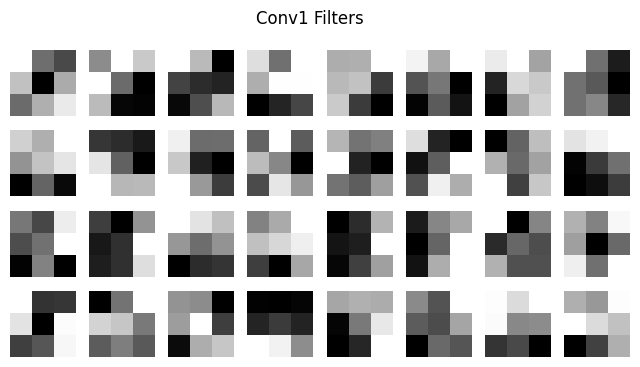

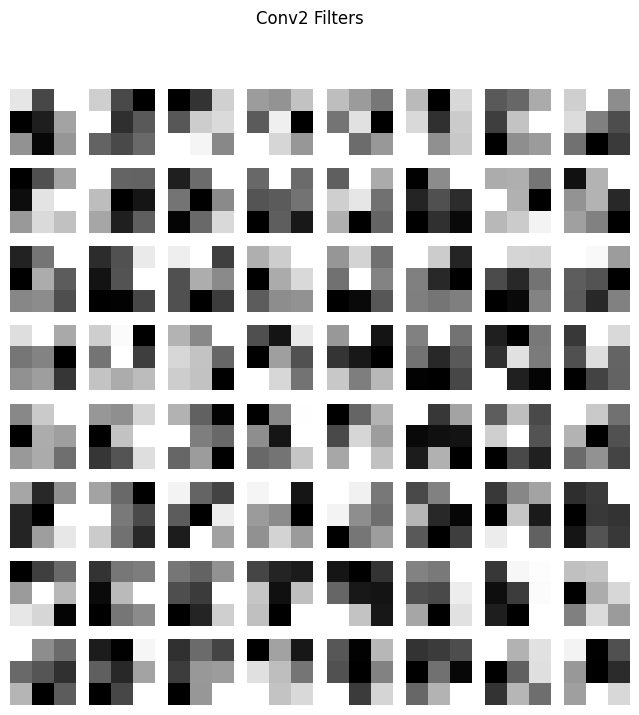

In [23]:
model = Net_BatchNorm()
model.load_state_dict(torch.load("mnist_cnn_adam_batchnorm.pt"))
# visualize conv layers
show_filters(model.conv1.weight, "Conv1 Filters")
show_filters(model.conv2.weight, "Conv2 Filters")
# show_filters(model.fc1.weight.view(-1, 1, 16, 8), "FC1 Weights Reshaped")
# show_filters(model.fc2.weight.view(-1, 1, 16, 8), "FC2 Weights Reshaped")



In [24]:
class Net_GroupNorm(nn.Module):
    def __init__(self):
        super(Net_GroupNorm, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, 1)
        self.conv2 = nn.Conv2d(32, 64, 3, 1)
        self.dropout1 = nn.Dropout(0.25)
        self.dropout2 = nn.Dropout(0.5)
        self.fc1 = nn.Linear(9216, 128)
        self.fc2 = nn.Linear(128, 10)
        self.gn1 = nn.GroupNorm(8, 32)
        self.gn2 = nn.GroupNorm(8, 64)

    def forward(self, x):
        x = self.conv1(x)
        x = self.gn1(x)
        x = F.relu(x)
        x = self.conv2(x)
        x = self.gn2(x)
        x = F.relu(x)
        x = F.max_pool2d(x, 2)
        x = self.dropout1(x)
        x = torch.flatten(x, 1)
        x = self.fc1(x)
        x = F.relu(x)
        x = self.dropout2(x)
        x = self.fc2(x)
        output = F.log_softmax(x, dim=1)
        return output


In [27]:
def main_adam_groupnorm():
    
    sys.argv = ['']

    # Training settings
    parser = argparse.ArgumentParser(description='PyTorch MNIST Example')
    parser.add_argument('--batch-size', type=int, default=64, metavar='N',
                        help='input batch size for training (default: 64)')
    parser.add_argument('--test-batch-size', type=int, default=1000, metavar='N',
                        help='input batch size for testing (default: 1000)')
    parser.add_argument('--epochs', type=int, default=14, metavar='N',
                        help='number of epochs to train (default: 14)')
    parser.add_argument('--lr', type=float, default=1.0, metavar='LR',
                        help='learning rate (default: 1.0)')
    parser.add_argument('--gamma', type=float, default=0.7, metavar='M',
                        help='Learning rate step gamma (default: 0.7)')
    parser.add_argument('--no-accel', action='store_true',
                        help='disables accelerator')
    parser.add_argument('--dry-run', action='store_true',
                        help='quickly check a single pass')
    parser.add_argument('--seed', type=int, default=1, metavar='S',
                        help='random seed (default: 1)')
    parser.add_argument('--log-interval', type=int, default=10, metavar='N',
                        help='how many batches to wait before logging training status')
    parser.add_argument('--save-model', action='store_true', 
                        help='For Saving the current Model')
    args = parser.parse_args()
    args.save_model = True


    use_accel = not args.no_accel and torch.accelerator.is_available()

    torch.manual_seed(args.seed)

    if use_accel:
        device = torch.accelerator.current_accelerator()
    else:
        device = torch.device("cpu")

    train_kwargs = {'batch_size': args.batch_size}
    test_kwargs = {'batch_size': args.test_batch_size}
    if use_accel:
        accel_kwargs = {'num_workers': 1,
                        'persistent_workers': True,
                       'pin_memory': True,
                       'shuffle': True}
        train_kwargs.update(accel_kwargs)
        test_kwargs.update(accel_kwargs)

    transform=transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))
        ])
    dataset1 = datasets.MNIST('../data', train=True, download=True,
                       transform=transform)
    dataset2 = datasets.MNIST('../data', train=False,
                       transform=transform)
    train_loader = torch.utils.data.DataLoader(dataset1,**train_kwargs)
    test_loader = torch.utils.data.DataLoader(dataset2, **test_kwargs)

    model = Net_GroupNorm().to(device)

    optimizer = optim.Adam(model.parameters(), lr=0.01, betas=(0.9, 0.999))

    scheduler = StepLR(optimizer, step_size=1, gamma=args.gamma)
    for epoch in range(1, args.epochs + 1):
        train(args, model, device, train_loader, optimizer, epoch)
        test(model, device, test_loader)
        scheduler.step()

    if args.save_model:
        torch.save(model.state_dict(), "mnist_cnn_adam_groupnorm.pt")

In [ ]:
main_adam_groupnorm()
'''
GroupNorm model with Adam optimizer
optimizer = optim.Adam(model.parameters(), lr=0.01, betas=(0.9, 0.999))
Test set: Average loss: 0.0373, Accuracy: 9905/10000 (99%)

'''

Train Epoch: 1 [0/60000 (0%)]	Loss: 2.393244
Train Epoch: 1 [640/60000 (1%)]	Loss: 2.127675
Train Epoch: 1 [1280/60000 (2%)]	Loss: 1.689615
Train Epoch: 1 [1920/60000 (3%)]	Loss: 1.618227
Train Epoch: 1 [2560/60000 (4%)]	Loss: 1.461939
Train Epoch: 1 [3200/60000 (5%)]	Loss: 1.264604
Train Epoch: 1 [3840/60000 (6%)]	Loss: 1.385481
Train Epoch: 1 [4480/60000 (7%)]	Loss: 1.217778
Train Epoch: 1 [5120/60000 (9%)]	Loss: 1.531035
Train Epoch: 1 [5760/60000 (10%)]	Loss: 1.327949
Train Epoch: 1 [6400/60000 (11%)]	Loss: 1.142339
Train Epoch: 1 [7040/60000 (12%)]	Loss: 1.152959
Train Epoch: 1 [7680/60000 (13%)]	Loss: 1.139345
Train Epoch: 1 [8320/60000 (14%)]	Loss: 1.223134
Train Epoch: 1 [8960/60000 (15%)]	Loss: 1.086034
Train Epoch: 1 [9600/60000 (16%)]	Loss: 1.422279
Train Epoch: 1 [10240/60000 (17%)]	Loss: 1.344761
Train Epoch: 1 [10880/60000 (18%)]	Loss: 1.092546
Train Epoch: 1 [11520/60000 (19%)]	Loss: 1.828579
Train Epoch: 1 [12160/60000 (20%)]	Loss: 1.381839
Train Epoch: 1 [12800/60000 (

'\nGroupNorm model with Adam optimizer\noptimizer = optim.Adam(model.parameters(), lr=0.01, betas=(0.9, 0.999))\n\n\n'

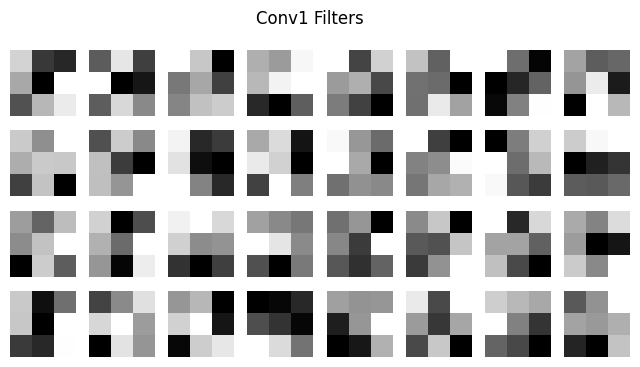

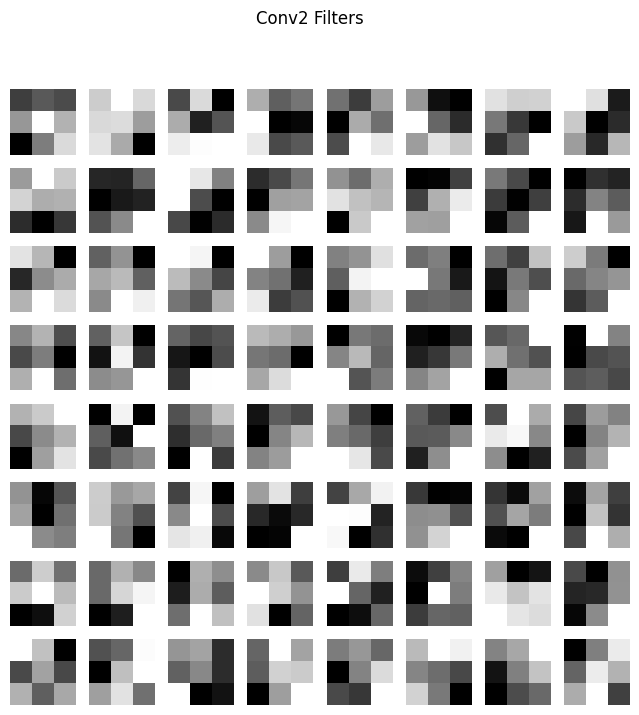

In [29]:
model = Net_GroupNorm()
model.load_state_dict(torch.load("mnist_cnn_adam_groupnorm.pt"))
# visualize conv layers
show_filters(model.conv1.weight, "Conv1 Filters")
show_filters(model.conv2.weight, "Conv2 Filters")
# show_filters(model.fc1.weight.view(-1, 1, 16, 8), "FC1 Weights Reshaped")
# show_filters(model.fc2.weight.view(-1, 1, 16, 8), "FC2 Weights Reshaped")



In [30]:
class Net_InstanceNorm(nn.Module):
    def __init__(self):
        super(Net_InstanceNorm, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, 1)
        self.conv2 = nn.Conv2d(32, 64, 3, 1)
        self.dropout1 = nn.Dropout(0.25)
        self.dropout2 = nn.Dropout(0.5)
        self.fc1 = nn.Linear(9216, 128)
        self.fc2 = nn.Linear(128, 10)
        self.in1 = nn.InstanceNorm2d(32)
        self.in2 = nn.InstanceNorm2d(64)

    def forward(self, x):
        x = self.conv1(x)
        x = self.in1(x)
        x = F.relu(x)
        x = self.conv2(x)
        x = self.in2(x)
        x = F.relu(x)
        x = F.max_pool2d(x, 2)
        x = self.dropout1(x)
        x = torch.flatten(x, 1)
        x = self.fc1(x)
        x = F.relu(x)
        x = self.dropout2(x)
        x = self.fc2(x)
        output = F.log_softmax(x, dim=1)
        return output


In [31]:
def main_adam_instancenorm():
    
    sys.argv = ['']

    # Training settings
    parser = argparse.ArgumentParser(description='PyTorch MNIST Example')
    parser.add_argument('--batch-size', type=int, default=64, metavar='N',
                        help='input batch size for training (default: 64)')
    parser.add_argument('--test-batch-size', type=int, default=1000, metavar='N',
                        help='input batch size for testing (default: 1000)')
    parser.add_argument('--epochs', type=int, default=14, metavar='N',
                        help='number of epochs to train (default: 14)')
    parser.add_argument('--lr', type=float, default=1.0, metavar='LR',
                        help='learning rate (default: 1.0)')
    parser.add_argument('--gamma', type=float, default=0.7, metavar='M',
                        help='Learning rate step gamma (default: 0.7)')
    parser.add_argument('--no-accel', action='store_true',
                        help='disables accelerator')
    parser.add_argument('--dry-run', action='store_true',
                        help='quickly check a single pass')
    parser.add_argument('--seed', type=int, default=1, metavar='S',
                        help='random seed (default: 1)')
    parser.add_argument('--log-interval', type=int, default=10, metavar='N',
                        help='how many batches to wait before logging training status')
    parser.add_argument('--save-model', action='store_true', 
                        help='For Saving the current Model')
    args = parser.parse_args()
    args.save_model = True


    use_accel = not args.no_accel and torch.accelerator.is_available()

    torch.manual_seed(args.seed)

    if use_accel:
        device = torch.accelerator.current_accelerator()
    else:
        device = torch.device("cpu")

    train_kwargs = {'batch_size': args.batch_size}
    test_kwargs = {'batch_size': args.test_batch_size}
    if use_accel:
        accel_kwargs = {'num_workers': 1,
                        'persistent_workers': True,
                       'pin_memory': True,
                       'shuffle': True}
        train_kwargs.update(accel_kwargs)
        test_kwargs.update(accel_kwargs)

    transform=transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))
        ])
    dataset1 = datasets.MNIST('../data', train=True, download=True,
                       transform=transform)
    dataset2 = datasets.MNIST('../data', train=False,
                       transform=transform)
    train_loader = torch.utils.data.DataLoader(dataset1,**train_kwargs)
    test_loader = torch.utils.data.DataLoader(dataset2, **test_kwargs)

    model = Net_InstanceNorm().to(device)

    optimizer = optim.Adam(model.parameters(), lr=0.01, betas=(0.9, 0.999))

    scheduler = StepLR(optimizer, step_size=1, gamma=args.gamma)
    for epoch in range(1, args.epochs + 1):
        train(args, model, device, train_loader, optimizer, epoch)
        test(model, device, test_loader)
        scheduler.step()

    if args.save_model:
        torch.save(model.state_dict(), "mnist_cnn_adam_instancenorm.pt")

In [ ]:
main_adam_instancenorm()
'''
InstanceNorm model with Adam optimizer
optimizer = optim.Adam(model.parameters(), lr=0.01, betas=(0.9, 0.999))
Test set: Average loss: 0.5443, Accuracy: 8751/10000 (88%)

'''

Train Epoch: 1 [0/60000 (0%)]	Loss: 2.368529
Train Epoch: 1 [640/60000 (1%)]	Loss: 2.058616
Train Epoch: 1 [1280/60000 (2%)]	Loss: 2.075907
Train Epoch: 1 [1920/60000 (3%)]	Loss: 1.699031
Train Epoch: 1 [2560/60000 (4%)]	Loss: 1.730584
Train Epoch: 1 [3200/60000 (5%)]	Loss: 1.831294
Train Epoch: 1 [3840/60000 (6%)]	Loss: 1.478165
Train Epoch: 1 [4480/60000 (7%)]	Loss: 1.610692
Train Epoch: 1 [5120/60000 (9%)]	Loss: 1.888177
Train Epoch: 1 [5760/60000 (10%)]	Loss: 2.113302
Train Epoch: 1 [6400/60000 (11%)]	Loss: 1.466295
Train Epoch: 1 [7040/60000 (12%)]	Loss: 1.670440
Train Epoch: 1 [7680/60000 (13%)]	Loss: 1.446375
Train Epoch: 1 [8320/60000 (14%)]	Loss: 1.650178
Train Epoch: 1 [8960/60000 (15%)]	Loss: 1.331318
Train Epoch: 1 [9600/60000 (16%)]	Loss: 1.808913
Train Epoch: 1 [10240/60000 (17%)]	Loss: 1.759344
Train Epoch: 1 [10880/60000 (18%)]	Loss: 1.701336
Train Epoch: 1 [11520/60000 (19%)]	Loss: 1.673213
Train Epoch: 1 [12160/60000 (20%)]	Loss: 1.676623
Train Epoch: 1 [12800/60000 (

'\nInstanceNorm model with Adam optimizer\noptimizer = optim.Adam(model.parameters(), lr=0.01, betas=(0.9, 0.999))\n\n\n'

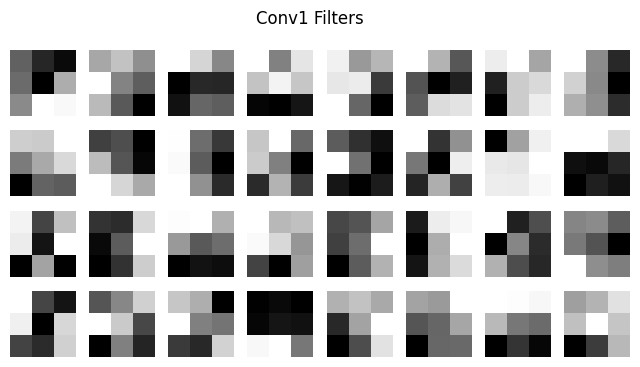

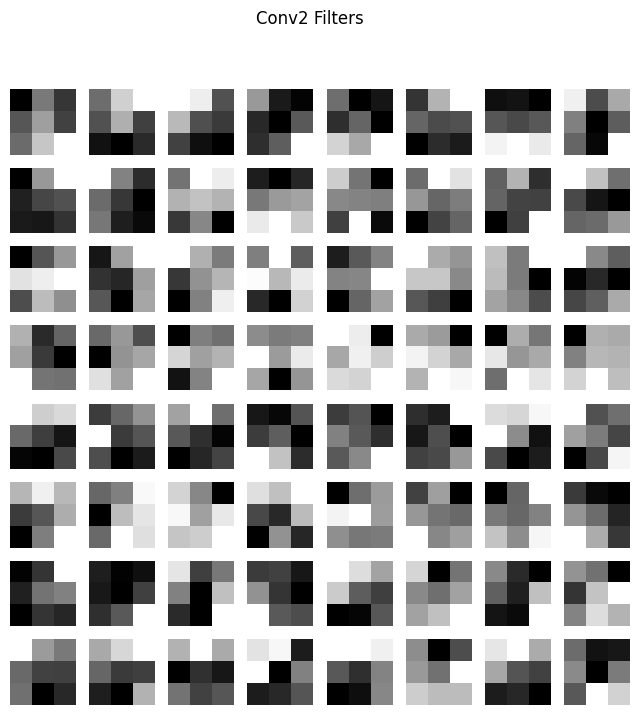

In [33]:
model = Net_InstanceNorm()
model.load_state_dict(torch.load("mnist_cnn_adam_instancenorm.pt"))
# visualize conv layers
show_filters(model.conv1.weight, "Conv1 Filters")
show_filters(model.conv2.weight, "Conv2 Filters")
# show_filters(model.fc1.weight.view(-1, 1, 16, 8), "FC1 Weights Reshaped")
# show_filters(model.fc2.weight.view(-1, 1, 16, 8), "FC2 Weights Reshaped")



In [ ]:
from torchvision.models import resnet18
